In [1]:
!pip install h2o flaml pandas scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 12.4 MB/s eta 0:00:00


In [3]:
!pip install mljar-supervised -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import h2o
from h2o.automl import H2OAutoML
from flaml import AutoML
import requests
import io
from supervised import AutoML as MLJAR_AutoML


In [16]:
import matplotlib.pyplot as plt

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

Загрузка данных

In [6]:
url = "https://raw.githubusercontent.com/KateAndri/StudyRepo26/main/data/dispensarization_data_2026.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

print(f"Данные загружены: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

# Определяем целевую переменную
TARGET = 'Доклинический_риск'
print(f"Целевая переменная: {TARGET}")

Данные загружены: (1000, 18)
Колонки: ['Возраст', 'Пол_мужской', 'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Пульсовое_давление', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин', 'Курение', 'Физическая_активность_мин_нед', 'ССЗ_риск_высокий', 'Статус_глюкозы', 'Доклинический_риск']
Целевая переменная: Доклинический_риск


Предобработка данных

In [7]:
# Проверяем пропуски
print(f"Пропуски до обработки: {df.isnull().sum().sum()}")

# Заполняем пропуски (простая обработка)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print(f"Пропуски после обработки: {df.isnull().sum().sum()}")

# Преобразуем категориальные признаки в числовые
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include=['object']).columns:
    if col != TARGET:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
        print(f"  {col}: закодирован")


Пропуски до обработки: 223
Пропуски после обработки: 0


/tmp/ipykernel_5834/11691830.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Разделение данных

In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка: {X_test.shape[0]} наблюдений")
print(f"Доля риска в train: {y_train.mean():.2%}")
print(f"Доля риска в test: {y_test.mean():.2%}")

Обучающая выборка: 800 наблюдений
Тестовая выборка: 200 наблюдений
Доля риска в train: 6.12%
Доля риска в test: 6.00%


Обучение FLAML AutoML

In [9]:
# Создаем и обучаем FLAML модель
automl_flaml = AutoML()
automl_flaml.fit(
    X_train=X_train,
    y_train=y_train,
    task='classification',
    time_budget=120,  # 2 минуты на обучение
    metric='roc_auc',
    verbose=True
)

# Предсказания
y_pred_flaml = automl_flaml.predict(X_test)
y_proba_flaml = automl_flaml.predict_proba(X_test)[:, 1]

# Метрики FLAML
accuracy_flaml = accuracy_score(y_test, y_pred_flaml)
precision_flaml = precision_score(y_test, y_pred_flaml)
recall_flaml = recall_score(y_test, y_pred_flaml)
f1_flaml = f1_score(y_test, y_pred_flaml)
auc_flaml = roc_auc_score(y_test, y_proba_flaml)

print(f"\nРезультаты FLAML:")
print(f"   Accuracy:  {accuracy_flaml:.4f}")
print(f"   Precision: {precision_flaml:.4f}")
print(f"   Recall:    {recall_flaml:.4f}")
print(f"   F1-Score:  {f1_flaml:.4f}")
print(f"   AUC-ROC:   {auc_flaml:.4f}")

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



Результаты FLAML:
   Accuracy:  0.9900
   Precision: 1.0000
   Recall:    0.8333
   F1-Score:  0.9091
   AUC-ROC:   0.9987


Обучение MLJAR AutoML

In [13]:
# Создаем модель
automl_mljar = MLJAR_AutoML(
    mode="Perform",
    total_time_limit=120,
    random_state=42
)

# ПРАВИЛЬНЫЙ синтаксис - передаем X и y отдельно
automl_mljar.fit(X_train, y_train)

# Предсказания
y_pred_mljar = automl_mljar.predict(X_test)
y_proba_mljar = automl_mljar.predict_proba(X_test)[:, 1]

# Метрики MLJAR
accuracy_mljar = accuracy_score(y_test, y_pred_mljar)
precision_mljar = precision_score(y_test, y_pred_mljar)
recall_mljar = recall_score(y_test, y_pred_mljar)
f1_mljar = f1_score(y_test, y_pred_mljar)
auc_mljar = roc_auc_score(y_test, y_proba_mljar)

print(f"\n📊 Результаты MLJAR AutoML:")
print(f"   Accuracy:  {accuracy_mljar:.4f}")
print(f"   Precision: {precision_mljar:.4f}")
print(f"   Recall:    {recall_mljar:.4f}")
print(f"   F1-Score:  {f1_mljar:.4f}")
print(f"   AUC-ROC:   {auc_mljar:.4f}")

AutoML directory: AutoML_1
The task is binary_classification with evaluation metric logloss
AutoML will use algorithms: ['Linear', 'Random Forest', 'LightGBM', 'Xgboost', 'CatBoost', 'Neural Network']
AutoML will ensemble available models
AutoML steps: ['simple_algorithms', 'default_algorithms', 'not_so_random', 'golden_features', 'insert_random_feature', 'features_selection', 'hill_climbing_1', 'hill_climbing_2', 'ensemble']
* Step simple_algorithms will try to check up to 1 model
1_Linear logloss 0.165914 trained in 37.78 seconds (1-sample predict time 0.0936 seconds)
Skip default_algorithms because of the time limit.
* Step not_so_random will try to check up to 20 models
6_LightGBM logloss 0.046849 trained in 8.73 seconds (1-sample predict time 0.0362 seconds)
2_Xgboost logloss 0.087742 trained in 8.67 seconds (1-sample predict time 0.0395 seconds)
10_CatBoost logloss 0.03795 trained in 24.91 seconds (1-sample predict time 0.041 seconds)
Skip golden_features because of the time limi

Сравнение

In [14]:
comparison_df = pd.DataFrame({
    'Фреймворк': ['FLAML', 'MLJAR AutoML'],
    'Accuracy': [accuracy_flaml, accuracy_mljar],
    'Precision': [precision_flaml, precision_mljar],
    'Recall': [recall_flaml, recall_mljar],
    'F1-Score': [f1_flaml, f1_mljar],
    'AUC-ROC': [auc_flaml, auc_mljar]
})

print("\n" + comparison_df.to_string(index=False))

# Определяем лучший фреймворк
if auc_flaml > auc_mljar:
    best_framework = "FLAML"
    best_auc = auc_flaml
    best_metrics = {
        'Accuracy': accuracy_flaml,
        'Precision': precision_flaml,
        'Recall': recall_flaml,
        'F1-Score': f1_flaml
    }
else:
    best_framework = "MLJAR AutoML"
    best_auc = auc_mljar
    best_metrics = {
        'Accuracy': accuracy_mljar,
        'Precision': precision_mljar,
        'Recall': recall_mljar,
        'F1-Score': f1_mljar
    }

print(f"\nЛУЧШИЙ ФРЕЙМВОРК: {best_framework}")
print(f"   AUC-ROC = {best_auc:.4f}")


   Фреймворк  Accuracy  Precision   Recall  F1-Score  AUC-ROC
       FLAML      0.99        1.0 0.833333  0.909091  0.99867
MLJAR AutoML      0.99        1.0 0.833333  0.909091  1.00000

ЛУЧШИЙ ФРЕЙМВОРК: MLJAR AutoML
   AUC-ROC = 1.0000


Визуализация

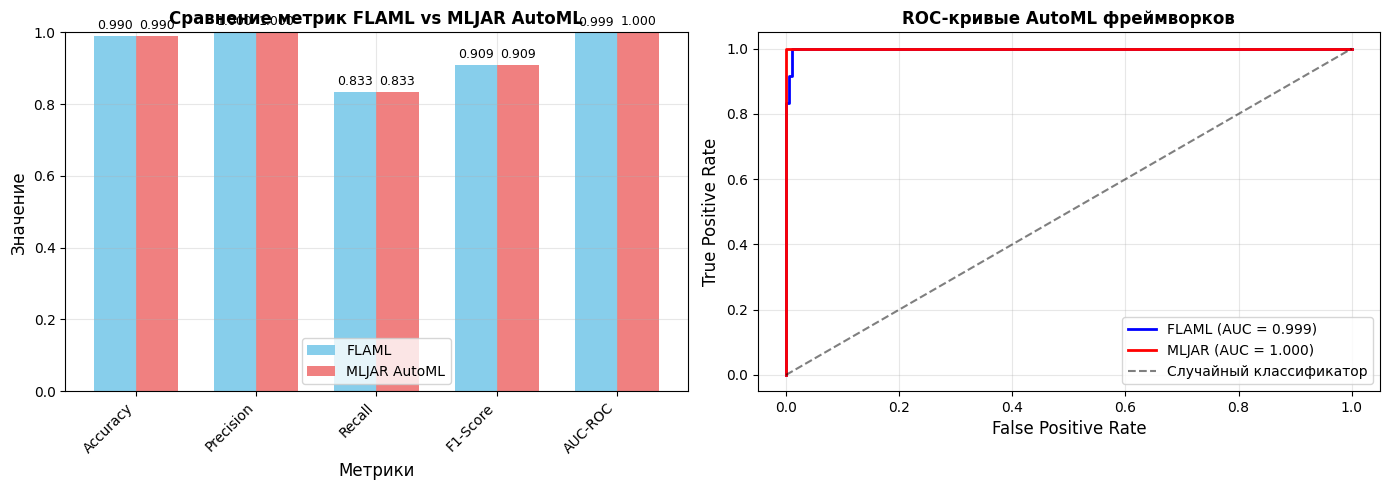

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение метрик
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
flaml_scores = [accuracy_flaml, precision_flaml, recall_flaml, f1_flaml, auc_flaml]
mljar_scores = [accuracy_mljar, precision_mljar, recall_mljar, f1_mljar, auc_mljar]

x = range(len(metrics))
width = 0.35

bars1 = axes[0].bar([i - width/2 for i in x], flaml_scores, width, label='FLAML', color='skyblue')
bars2 = axes[0].bar([i + width/2 for i in x], mljar_scores, width, label='MLJAR AutoML', color='lightcoral')
axes[0].set_xlabel('Метрики', fontsize=12)
axes[0].set_ylabel('Значение', fontsize=12)
axes[0].set_title('Сравнение метрик FLAML vs MLJAR AutoML', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, (f, a) in enumerate(zip(flaml_scores, mljar_scores)):
    axes[0].text(i - width/2, f + 0.02, f'{f:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, a + 0.02, f'{a:.3f}', ha='center', fontsize=9)

# График 2: ROC-кривые
fpr_flaml, tpr_flaml, _ = roc_curve(y_test, y_proba_flaml)
fpr_mljar, tpr_mljar, _ = roc_curve(y_test, y_proba_mljar)

axes[1].plot(fpr_flaml, tpr_flaml, 'b-', linewidth=2, label=f'FLAML (AUC = {auc_flaml:.3f})')
axes[1].plot(fpr_mljar, tpr_mljar, 'r-', linewidth=2, label=f'MLJAR (AUC = {auc_mljar:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', alpha=0.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC-кривые AutoML фреймворков', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод: фреймворк MLJAR AutoML оказался эффективнее. Это подтверждают визиализация и пункт сравнение.